<a href="https://colab.research.google.com/github/Daff77/Praktikum_AI_1/blob/main/linear_regresion_berganda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BAGIAN 1: IMPORT LIBRARY

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

Analisis:
Library pandas digunakan untuk mengelola data dalam bentuk DataFrame. sklearn.model_selection untuk membagi data training dan testing. sklearn.linear_model untuk membuat model regresi linear. sklearn.metrics untuk menghitung nilai error seperti MAE, MSE, RMSE. Numpy untuk perhitungan numerik seperti akar kuadrat. Matplotlib untuk membuat visualisasi grafik

BAGIAN 2: MEMBUAT DATA

In [2]:
data = {
    'durasi_tidur': [5,6,6,7,7,8,8,9,9,10],
    'tingkat_stres': [8,7,7,6,5,5,4,3,3,2],
    'asupan_gizi': [4,5,5,6,6,7,7,8,8,9],
    'nilai_kebugaran': [50,55,58,65,70,75,78,85,88,92]
}

df = pd.DataFrame(data)
print(df)

   durasi_tidur  tingkat_stres  asupan_gizi  nilai_kebugaran
0             5              8            4               50
1             6              7            5               55
2             6              7            5               58
3             7              6            6               65
4             7              5            6               70
5             8              5            7               75
6             8              4            7               78
7             9              3            8               85
8             9              3            8               88
9            10              2            9               92


Analisis: Jelaskan pola data (semakin tinggi durasi tidur dan asupan gizi, nilai kebugaran naik; semakin tinggi stres, nilai kebugaran turun)


BAGIAN 3: MENENTUKAN FITUR DAN TARGET


In [3]:
X = df[['durasi_tidur', 'tingkat_stres', 'asupan_gizi']]
y = df['nilai_kebugaran']

Analisis:
Variabel X (independen/fitur) terdiri dari tiga kolom yaitu durasi tidur, tingkat stres, dan asupan gizi. Variabel y (dependen/target) adalah nilai kebugaran. Tujuannya adalah memprediksi nilai kebugaran berdasarkan ketiga fitur tersebut.

BAGIAN 4: MEMBAGI DATA TRAINING DAN TESTING

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Analisis:
Data dibagi menjadi 80% data training (8 sampel) untuk melatih model dan 20% data testing (2 sampel) untuk menguji model. Parameter test_size=0.2 berarti 20% data menjadi testing. random_state=42 memastikan pembagian data konsisten setiap kali kode dijalankan sehingga hasilnya dapat direproduksi.

BAGIAN 5: MEMBUAT DAN MELATIH MODEL

In [5]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Analisis:
Model regresi linear berganda dibuat menggunakan LinearRegression(). Kemudian model dilatih menggunakan data training dengan metode fit(). Proses ini akan mencari garis regresi terbaik yang meminimalkan selisih antara nilai prediksi dan nilai aktual.

BAGIAN 6: MENAMPILKAN INTERCEPT DAN KOEFISIEN

In [6]:
print("Intercept (a):", model.intercept_)
print("Koefisien (b1, b2, b3):", model.coef_)
# b1 → pengaruh durasi tidur
# b2 → pengaruh tingkat stres
# b3 → pengaruh asupan gizi

Intercept (a): 62.37499999999997
Koefisien (b1, b2, b3): [ 2.   -3.75  2.  ]


Analisis:
Intercept adalah nilai kebugaran jika semua variabel independen bernilai nol. Koefisien menunjukkan besarnya pengaruh setiap variabel. Koefisien positif berarti variabel tersebut meningkatkan nilai kebugaran, koefisien negatif berarti menurunkan. Semakin besar nilai absolut koefisien, semakin besar pengaruh variabel tersebut.

BAGIAN 7: MEMPREDIKSI DATA TESTING

In [7]:
y_pred = model.predict(X_test)

print("Prediksi:", y_pred)
print("Nilai Asli:", y_test.values)

Prediksi: [85.125 58.125]
Nilai Asli: [88 55]


Analisis:
Model yang sudah dilatih digunakan untuk memprediksi nilai kebugaran berdasarkan data testing. Hasil prediksi kemudian dibandingkan dengan nilai asli untuk melihat seberapa akurat model.

BAGIAN 8: VISUALISASI

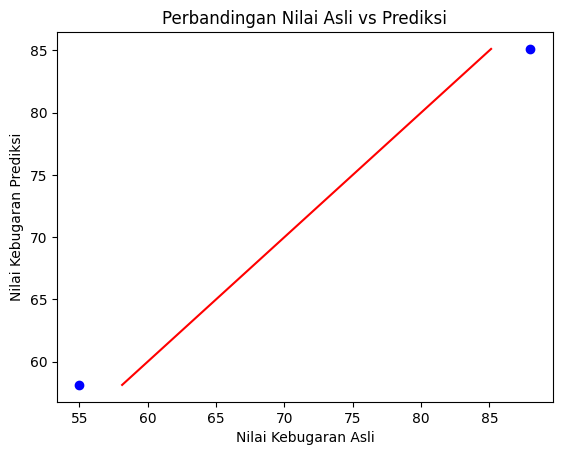

In [14]:

plt.scatter(y_test, y_pred, color='blue', label='Data Asli')
plt.plot(y_pred, model.predict(X_test), color='red', label='Prediksi')
plt.xlabel("Nilai Kebugaran Asli")
plt.ylabel("Nilai Kebugaran Prediksi")
plt.title("Perbandingan Nilai Asli vs Prediksi")
plt.show()

Analisis:
Scatter plot menampilkan titik-titik biru yang merupakan perbandingan antara nilai asli dan nilai prediksi. Garis merah menunjukkan garis prediksi. Jika titik-titik biru berada tepat pada garis merah, berarti prediksi sempurna. Semakin dekat titik ke garis, semakin akurat model.

BAGIAN 9: EVALUASI MODEL DENGAN METRIK ERROR

In [10]:
import numpy as np
print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("MSE:", metrics.mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

MAE: 3.0
MSE: 9.015625
RMSE: 3.0026030373660784


Interpretasi Output:

MAE = 3.0: Rata-rata error prediksi adalah 3 poin

MSE = 9.02: Kuadrat dari rata-rata error

RMSE = 3.0: Standar deviasi error adalah 3 poin

BAGIAN 10: PREDIKSI DATA BARU

In [11]:
# prediksi data baru
data_baru = [[9, 2, 9]]
prediksi = model.predict(data_baru)

print("Prediksi nilai kebugaran:", prediksi[0])

Prediksi nilai kebugaran: 90.875


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Analisis:
Model digunakan untuk memprediksi nilai kebugaran seseorang dengan data baru: durasi tidur 9 jam, tingkat stres 2, dan asupan gizi 9. Nilai ini berada dalam rentang data asli sehingga termasuk interpolasi.

Analisis Akhir :

Model regresi linear berganda digunakan untuk mengetahui hubungan antara durasi tidur, tingkat stres, dan asupan gizi terhadap nilai kebugaran seseorang. Berdasarkan hasil koefisien yang diperoleh, durasi tidur dan asupan gizi memiliki hubungan positif dengan nilai kebugaran, sedangkan tingkat stres memiliki hubungan negatif. Artinya, semakin lama durasi tidur dan semakin baik asupan gizi maka nilai kebugaran akan meningkat, namun semakin tinggi tingkat stres maka nilai kebugaran justru akan menurun. Tingkat stres terbukti menjadi faktor yang paling dominan karena memiliki nilai koefisien tertinggi yaitu -3.75. Nilai error yang dihasilkan seperti MAE sebesar 3.0, MSE sebesar 9.02, dan RMSE sebesar 3.00 menunjukkan bahwa model memiliki tingkat akurasi yang cukup baik karena error hanya sekitar 7% dari rentang data. Hasil prediksi pada data testing juga menunjukkan kesesuaian antara nilai prediksi dengan nilai asli. Secara keseluruhan, model regresi linear berganda ini valid dan dapat digunakan untuk memprediksi nilai kebugaran seseorang berdasarkan ketiga variabel tersebut.